**Data Cleaning & Reporting Automation**

1. Introduction

Data cleaning and reporting are important steps in data analysis. Raw datasets often contain missing values, duplicate records, inconsistent information, and invalid dates. These problems can affect the accuracy of analysis and reports.

This project focuses on developing an automated data cleaning and reporting workflow using Python, Pandas, Matplotlib, and Excel. The system cleans the raw sales data, performs analysis, generates visualizations, and creates an automated Excel report.

2. Problem Statement

Manually cleaning and preparing datasets can take considerable time and may lead to errors.

The objective of this project is to automate the process of:

Identifying missing values
Detecting duplicate records
Handling invalid dates
Cleaning inconsistent data
Generating sales summaries
Creating visualizations
Producing an Excel report
3. Objectives

The main objectives are:

Load and inspect the raw sales dataset.
Identify data quality problems.
Handle missing values.
Remove duplicate records.
Handle invalid dates.
Standardize inconsistent data.
Generate useful sales statistics.
Create visualizations.
Automatically generate an Excel report.
Reduce manual effort in data preparation and reporting.
4. Tools and Technologies
Tool	Purpose
Python	Data processing and automation
Pandas	Data cleaning and analysis
NumPy	Numerical operations
Matplotlib	Data visualization
OpenPyXL	Excel report generation
Google Colab	Development environment
Excel	Final reporting
5. Dataset

The project uses a sample/synthetic sales dataset containing sales transaction information.

The dataset includes fields such as:

Order ID
Order Date
Customer Name
Segment
City
Region
Category
Sub-Category
Product Name
Quantity
Sales
Discount

The dataset was intentionally prepared with data-quality issues so that the cleaning and automation workflow could be demonstrated.

6. Data Cleaning Process

The following steps were performed:

Missing Values

Missing values were identified using:

df.isnull().sum()

Appropriate values were then used to fill missing information.

Duplicate Records

Duplicate rows were identified using:

df.duplicated().sum()

Duplicate records were removed using:

df.drop_duplicates()
Invalid Dates

Order dates were converted into proper date format:

pd.to_datetime(df["Order_Date"], errors="coerce")

Invalid dates were then handled during the cleaning process.

Inconsistent Data

Text fields such as Category and City were standardized by removing unnecessary spaces and standardizing capitalization.

Example:

cleaned_df["City"] = cleaned_df["City"].str.strip()
7. Data Analysis

After cleaning the dataset, several analyses were performed.

Sales Summary

The system calculates:

Total Sales
Total Orders
Total Customers
Total Quantity
Average Sale
Category Analysis

Sales were grouped according to product category to understand category-level sales.

Regional Analysis

Sales were grouped by region to analyze regional performance.

Monthly Analysis

Sales were grouped by month to identify changes in sales over time.

Product Analysis

The top 10 products were identified based on total sales.

8. Data Visualization

The project generates the following visualizations:

Sales by Category
Sales by Region
Monthly Sales Trend
Top 10 Products by Sales

These charts make the analysis easier to understand and provide a visual summary of the cleaned data.

9. Automated Reporting

After cleaning and analyzing the data, the project automatically generates an Excel report.

The final Excel report contains:

Cleaning Summary
Sales Summary
Cleaned Data
Category Analysis
Region Analysis
Monthly Analysis
Top Products

This reduces the need to manually prepare reports every time the dataset is processed.

10. Project Workflow
Raw Dataset
     ↓
Load Dataset
     ↓
Data Quality Check
     ↓
Missing Value Detection
     ↓
Duplicate Detection
     ↓
Invalid Date Detection
     ↓
Data Cleaning
     ↓
Clean Dataset
     ↓
Data Analysis
     ↓
Visualization
     ↓
Automated Excel Report
11. Results

The project successfully demonstrates an automated workflow for cleaning and reporting sales data.

The system is able to identify and handle common data-quality issues, perform sales analysis, generate charts, and produce an Excel report automatically.

The workflow makes the reporting process more organized and reduces repetitive manual work.

12. Advantages
Reduces manual data-cleaning work
Saves time
Provides consistent processing
Makes data-quality problems easier to identify
Generates reports automatically
Provides visual summaries
Can be reused with similar datasets
13. Limitations
The project currently uses a sample/synthetic dataset.
The cleaning rules are designed for this dataset structure.
More complex real-world datasets may require additional validation rules.
The generated report is currently focused on sales-related analysis.
14. Future Scope

The project can be improved by:

Connecting directly to databases
Adding automated scheduled reports
Creating an interactive Power BI dashboard
Adding email-based report delivery
Supporting larger datasets
Adding more data-quality validation rules
Creating a web-based reporting interface
15. Conclusion

The Data Cleaning & Reporting Automation project demonstrates how Python can be used to automate important data-processing and reporting tasks.

The system identifies data-quality issues, cleans the dataset, performs analysis, creates visualizations, and generates an Excel report. This workflow provides a structured approach to transforming raw data into useful information while reducing repetitive manual reporting work.

step 1 -->



 Load the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("raw_sales_data_dirty.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 1005
Columns: 12


,Order_ID,Order_Date,Customer_Name,Segment,City,Region,Category,Sub_Category,Product_Name,Quantity,Sales,Discount
0,ORD10927,2025-11-07,Customer_927,Corporate,Bangalore,South,Office Supplies,Binders,Product_49,6,3352.85,0.40
1,ORD10631,2025-04-05,Customer_631,Corporate,Hyderabad,Central,Furniture,Chairs,Product_9,3,6713.23,0.40
2,ORD10683,2025-05-13,Customer_683,Consumer,Hyderabad,South,Office Supplies,Binders,Product_32,5,574.35,0.37
3,ORD10515,2025-01-10,Customer_515,Corporate,Hyderabad,South,furniture,Chairs,Product_16,7,NaN,0.28
4,ORD10366,2024-09-23,Customer_366,Corporate,Hyderabad,Central,Office Supplies,Storage,Product_27,4,8621.91,0.41


step 2 -->

Check the dataset information


In [ ]:
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1005 non-null   object 
 1   Order_Date     1005 non-null   object 
 2   Customer_Name  997 non-null    object 
 3   Segment        1005 non-null   object 
 4   City           1005 non-null   object 
 5   Region         999 non-null    object 
 6   Category       1005 non-null   object 
 7   Sub_Category   1005 non-null   object 
 8   Product_Name   1005 non-null   object 
 9   Quantity       1005 non-null   int64  
 10  Sales          999 non-null    float64
 11  Discount       1005 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 94.3+ KB
None


Check Missing Values and Duplicates

In [ ]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Order_ID         0
Order_Date       0
Customer_Name    8
Segment          0
City             0
Region           6
Category         0
Sub_Category     0
Product_Name     0
Quantity         0
Sales            6
Discount         0
dtype: int64


Check duplicate records

In [ ]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5


Check invalid dates

In [ ]:
# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

# Count invalid dates
invalid_dates = df["Order_Date"].isnull().sum()

print("Invalid dates:", invalid_dates)

Invalid dates: 6


Create a simple data-quality summary

In [ ]:
print("----- DATA QUALITY SUMMARY -----")
print("Total rows:", len(df))
print("Total columns:", len(df.columns))
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Invalid dates:", df["Order_Date"].isnull().sum())

----- DATA QUALITY SUMMARY -----
Total rows: 1005
Total columns: 12
Missing values: 26
Duplicate rows: 5
Invalid dates: 6


step 3-->

Clean the Dataset

In [ ]:
# ==========================================
# STEP 4: DATA CLEANING
# ==========================================

# Make a copy of the raw dataset
cleaned_df = df.copy()

# 1. Remove duplicate rows
before_duplicates = len(cleaned_df)

cleaned_df = cleaned_df.drop_duplicates()

after_duplicates = len(cleaned_df)

print("Duplicate rows removed:", before_duplicates - after_duplicates)


# 2. Handle missing Customer Names
cleaned_df["Customer_Name"] = cleaned_df["Customer_Name"].fillna("Unknown")


# 3. Handle missing Region
cleaned_df["Region"] = cleaned_df["Region"].fillna(
    cleaned_df["Region"].mode()[0]
)


# 4. Handle missing Sales
cleaned_df["Sales"] = cleaned_df["Sales"].fillna(
    cleaned_df["Sales"].median()
)


# 5. Clean text spaces
cleaned_df["City"] = cleaned_df["City"].str.strip()
cleaned_df["Category"] = cleaned_df["Category"].str.strip()


# 6. Standardize Category names
cleaned_df["Category"] = cleaned_df["Category"].str.title()


# 7. Handle invalid dates
# Invalid dates were converted to NaT in Step 3.
# Fill them using the most common valid date.
cleaned_df["Order_Date"] = cleaned_df["Order_Date"].fillna(
    cleaned_df["Order_Date"].median()
)


# 8. Sort data by Order Date
cleaned_df = cleaned_df.sort_values("Order_Date")


# 9. Reset row numbers
cleaned_df = cleaned_df.reset_index(drop=True)


# ==========================================
# CLEANING SUMMARY
# ==========================================

print("\n========== CLEANING COMPLETED ==========")

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(cleaned_df))

print("\nMissing values after cleaning:")
print(cleaned_df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(cleaned_df.duplicated().sum())

print("\nCleaned dataset preview:")
display(cleaned_df.head())

Duplicate rows removed: 5

========== CLEANING COMPLETED ==========
Rows before cleaning: 1005
Rows after cleaning: 1000

Missing values after cleaning:
Order_ID         0
Order_Date       0
Customer_Name    0
Segment          0
City             0
Region           0
Category         0
Sub_Category     0
Product_Name     0
Quantity         0
Sales            0
Discount         0
dtype: int64

Duplicate rows after cleaning:
0

Cleaned dataset preview:


,Order_ID,Order_Date,Customer_Name,Segment,City,Region,Category,Sub_Category,Product_Name,Quantity,Sales,Discount
0,ORD10002,2024-01-01,Customer_2,Consumer,Pune,West,Furniture,Bookcases,Product_13,1,2497.53,0.01
1,ORD10001,2024-01-01,Customer_1,Corporate,Pune,Central,Technology,Machines,Product_11,1,3146.26,0.03
2,ORD10003,2024-01-02,Customer_3,Consumer,Mumbai,East,Technology,Machines,Product_4,6,822.74,0.05
3,ORD10004,2024-01-03,Customer_4,Home Office,Hyderabad,West,Technology,Machines,Product_22,1,7465.88,0.09
4,ORD10005,2024-01-03,Unknown,Consumer,Mumbai,South,Furniture,Chairs,Product_7,6,7138.91,0.22


 Verify cleaning

In [ ]:
print("Remaining missing values:",
      cleaned_df.isnull().sum().sum())

print("Remaining duplicate rows:",
      cleaned_df.duplicated().sum())

Remaining missing values: 0
Remaining duplicate rows: 0


Save the cleaned dataset

In [ ]:
cleaned_df.to_csv("cleaned_sales_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


 step 4--> Create the Automated Sales Report

 Create basic business summary

In [ ]:
# ==========================================
# STEP 5: AUTOMATED SALES REPORT
# ==========================================

total_sales = cleaned_df["Sales"].sum()
total_orders = cleaned_df["Order_ID"].nunique()
total_customers = cleaned_df["Customer_Name"].nunique()
total_quantity = cleaned_df["Quantity"].sum()
average_sales = cleaned_df["Sales"].mean()

print("========== SALES REPORT ==========")
print(f"Total Sales       : ₹{total_sales:,.2f}")
print(f"Total Orders      : {total_orders}")
print(f"Total Customers   : {total_customers}")
print(f"Total Quantity    : {total_quantity}")
print(f"Average Sale      : ₹{average_sales:,.2f}")

========== SALES REPORT ==========
Total Sales       : ₹5,019,387.66
Total Orders      : 1000
Total Customers   : 993
Total Quantity    : 5064
Average Sale      : ₹5,019.39


Sales by Category

In [ ]:
# Sales by Category

category_sales = (
    cleaned_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("========== SALES BY CATEGORY ==========")
print(category_sales)

========== SALES BY CATEGORY ==========
Category
Furniture          1788119.150
Office Supplies    1616366.435
Technology         1614902.075
Name: Sales, dtype: float64


Sales by Region

In [ ]:
# Sales by Region

region_sales = (
    cleaned_df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("========== SALES BY REGION ==========")
print(region_sales)

========== SALES BY REGION ==========
Region
Central    1309173.630
South      1296504.950
East       1229809.485
West       1183899.595
Name: Sales, dtype: float64


Monthly Sales

In [ ]:
# Monthly Sales

cleaned_df["Month"] = cleaned_df["Order_Date"].dt.to_period("M")

monthly_sales = (
    cleaned_df.groupby("Month")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Month"] = monthly_sales["Month"].astype(str)

print("========== MONTHLY SALES ==========")
display(monthly_sales)

========== MONTHLY SALES ==========


,Month,Sales
0,2024-01,224931.955
1,2024-02,193420.240
2,2024-03,245505.240
3,2024-04,225550.910
4,2024-05,209259.825
5,2024-06,174386.410
6,2024-07,220388.390
7,2024-08,207043.260
8,2024-09,213066.970
9,2024-10,190727.030


Top 10 Products

In [ ]:
# Top 10 Products

top_products = (
    cleaned_df.groupby("Product_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("========== TOP 10 PRODUCTS ==========")
print(top_products)

========== TOP 10 PRODUCTS ==========
Product_Name
Product_40    151885.490
Product_23    141181.380
Product_38    132787.710
Product_32    126459.660
Product_21    125998.500
Product_15    125732.540
Product_22    125009.420
Product_20    123118.910
Product_45    122761.190
Product_13    122067.045
Name: Sales, dtype: float64


Create one complete report

In [ ]:
# ==========================================
# COMPLETE AUTOMATED REPORT
# ==========================================

report = {
    "Total Sales": total_sales,
    "Total Orders": total_orders,
    "Total Customers": total_customers,
    "Total Quantity": total_quantity,
    "Average Sale": average_sales
}

report_df = pd.DataFrame(
    report.items(),
    columns=["Metric", "Value"]
)

print("========== AUTOMATED SALES REPORT ==========")
display(report_df)

========== AUTOMATED SALES REPORT ==========


,Metric,Value
0,Total Sales,5.019388e+06
1,Total Orders,1.000000e+03
2,Total Customers,9.930000e+02
3,Total Quantity,5.064000e+03
4,Average Sale,5.019388e+03


step 5--> Create Professional Visualizations

Sales by Category

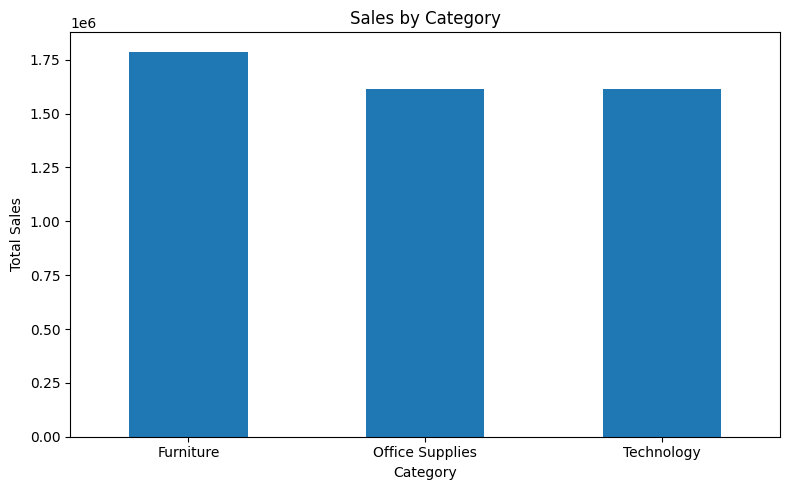

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Sales by Region

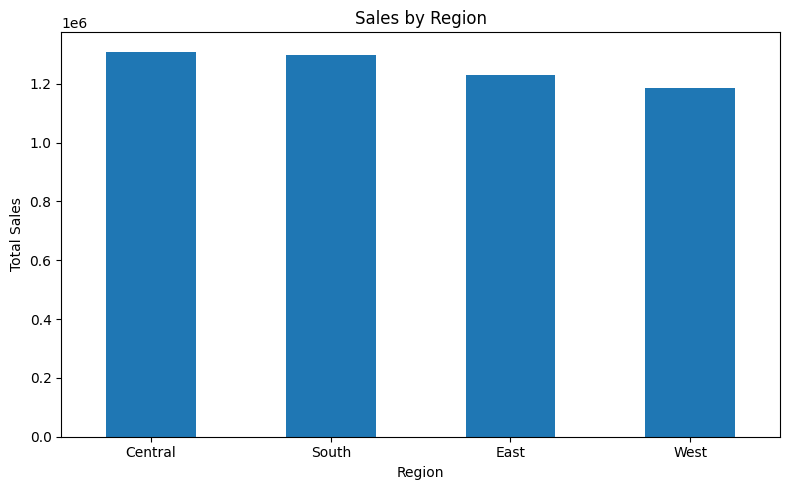

In [ ]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Monthly Sales Trend

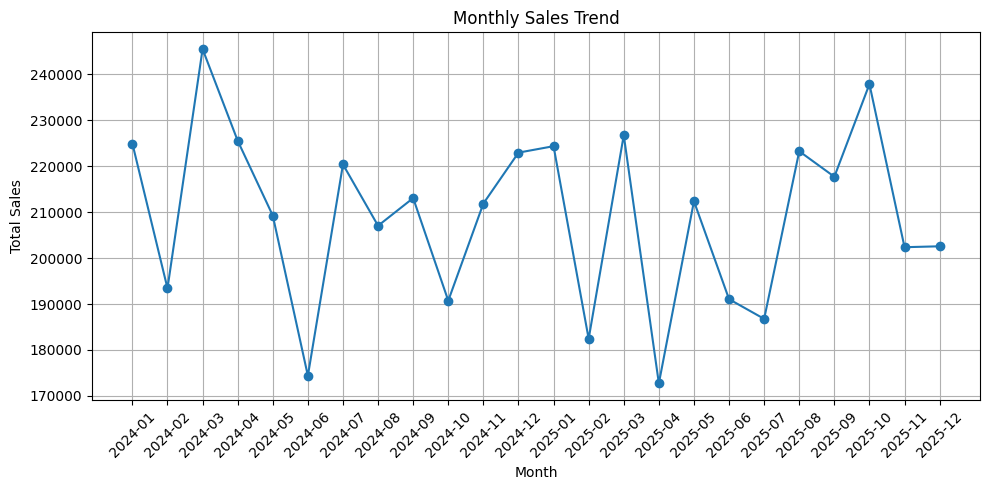

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

Top 10 Products

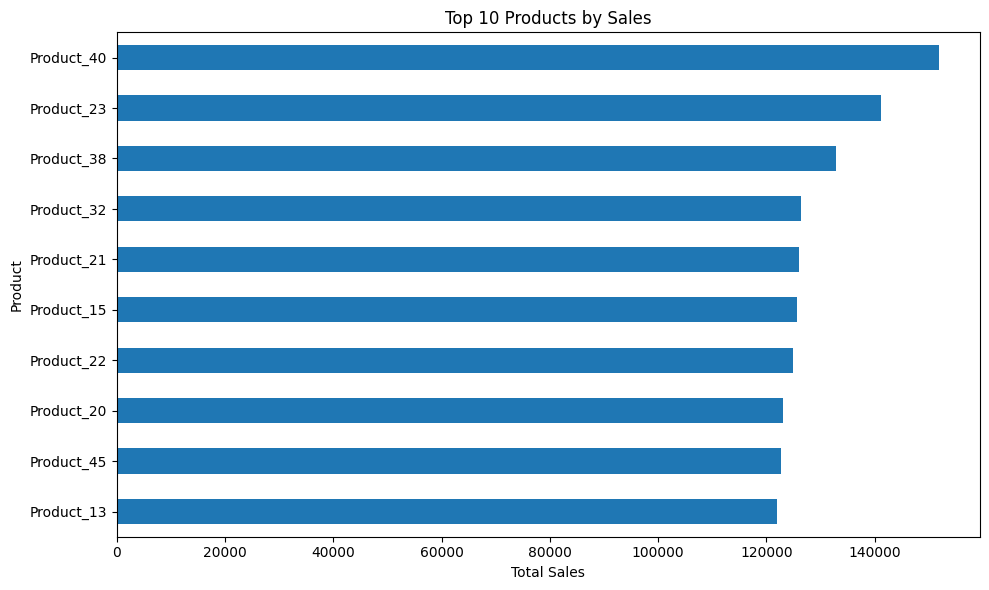

In [ ]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

Create One Professional Dashboard

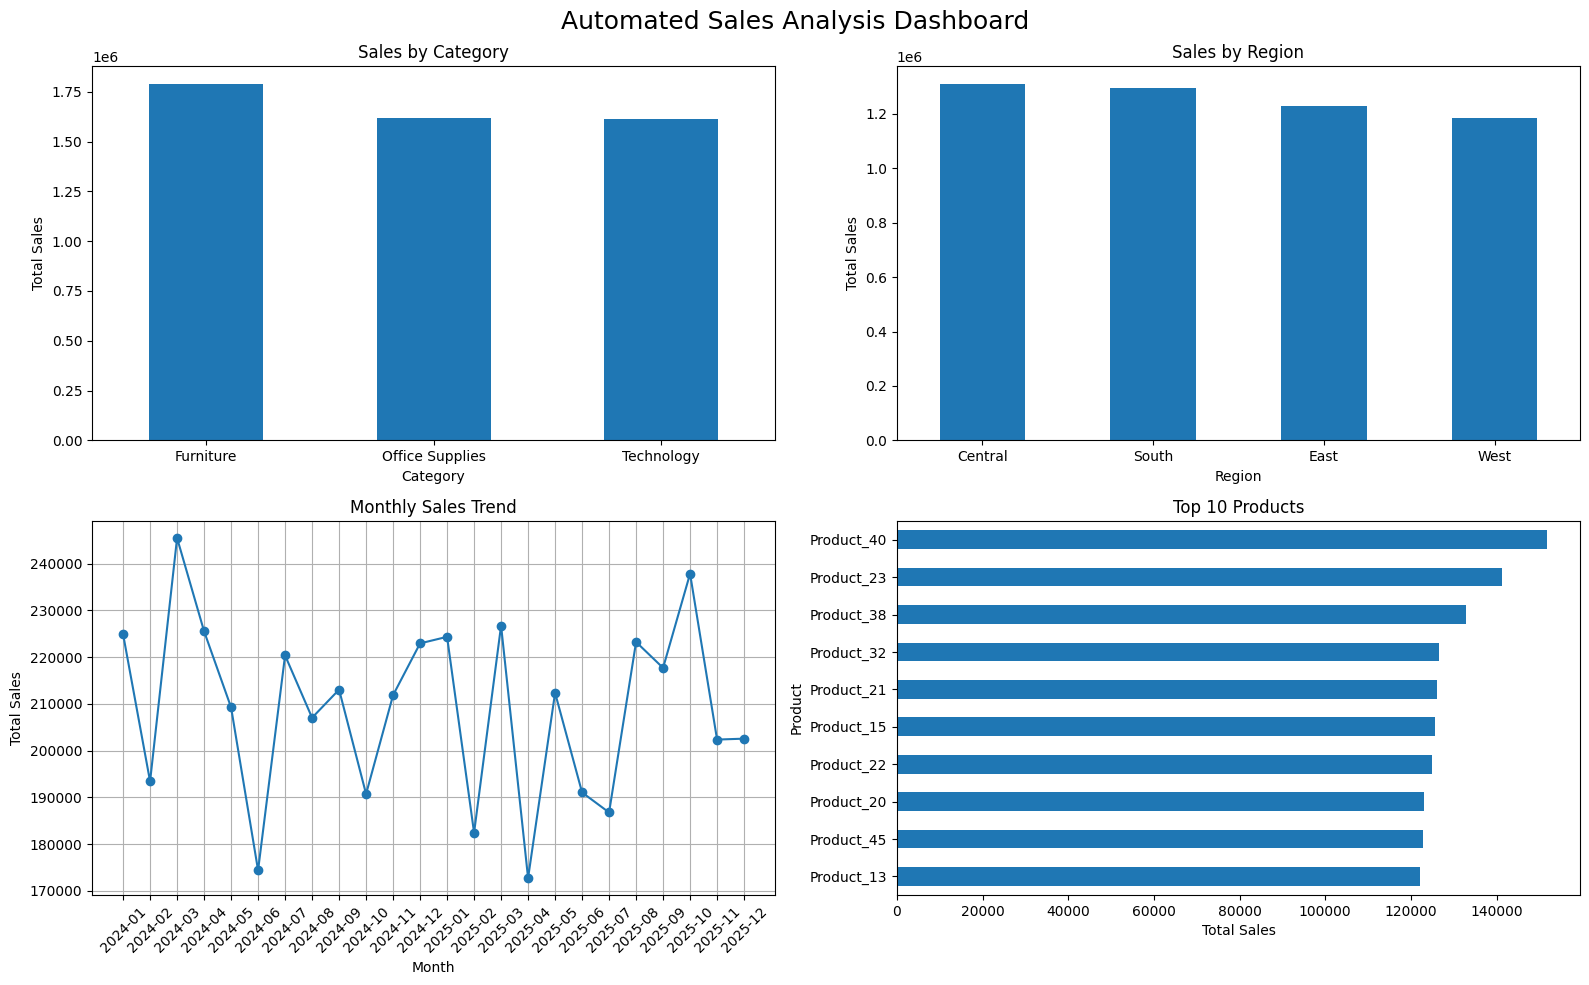

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Sales by Category
category_sales.plot(
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Sales by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Total Sales")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2. Sales by Region
region_sales.plot(
    kind="bar",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Sales by Region")
axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Total Sales")
axes[0, 1].tick_params(axis="x", rotation=0)

# 3. Monthly Sales
axes[1, 0].plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o"
)
axes[1, 0].set_title("Monthly Sales Trend")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Total Sales")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(True)

# 4. Top 10 Products
top_products.sort_values().plot(
    kind="barh",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Top 10 Products")
axes[1, 1].set_xlabel("Total Sales")
axes[1, 1].set_ylabel("Product")

plt.suptitle(
    "Automated Sales Analysis Dashboard",
    fontsize=18
)

plt.tight_layout()
plt.show()

step 6--> Generate an Automated Excel Report

Install/openpyxl

In [ ]:
!pip install openpyxl -q

Generate the Excel Report

In [ ]:
import pandas as pd

output_file = "Automated_Sales_Report.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # 1. Summary Report
    report_df.to_excel(
        writer,
        sheet_name="Summary Report",
        index=False
    )

    # 2. Cleaned Data
    cleaned_df.to_excel(
        writer,
        sheet_name="Cleaned Data",
        index=False
    )

    # 3. Sales by Category
    category_sales.reset_index().to_excel(
        writer,
        sheet_name="Sales by Category",
        index=False
    )

    # 4. Sales by Region
    region_sales.reset_index().to_excel(
        writer,
        sheet_name="Sales by Region",
        index=False
    )

    # 5. Monthly Sales
    monthly_sales.to_excel(
        writer,
        sheet_name="Monthly Sales",
        index=False
    )

    # 6. Top 10 Products
    top_products.reset_index().to_excel(
        writer,
        sheet_name="Top 10 Products",
        index=False
    )

print("Excel report created successfully!")
print("File name:", output_file)

Excel report created successfully!
File name: Automated_Sales_Report.xlsx


Make the Excel Report Professional

In [ ]:
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# Load workbook
wb = load_workbook("Automated_Sales_Report.xlsx")

# Format every sheet
for ws in wb.worksheets:

    # Header formatting
    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal="center")

    # Adjust column widths
    for column in ws.columns:
        max_length = 0
        column_letter = get_column_letter(column[0].column)

        for cell in column:
            if cell.value is not None:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        ws.column_dimensions[column_letter].width = min(
            max_length + 2,
            40
        )

# Save formatted workbook
wb.save("Automated_Sales_Report.xlsx")

print("Professional Excel report created successfully!")

Professional Excel report created successfully!


Download the Excel Report

In [ ]:
from google.colab import files

files.download("Automated_Sales_Report.xlsx")

step 7--> Create the Final Automated Report

Create Data Cleaning Summary

In [ ]:
# Data cleaning statistics

rows_before = len(df)
rows_after = len(cleaned_df)

missing_before = df.isnull().sum().sum()
missing_after = cleaned_df.isnull().sum().sum()

duplicates_before = df.duplicated().sum()
duplicates_after = cleaned_df.duplicated().sum()

invalid_dates = df["Order_Date"].isnull().sum()

cleaning_summary = pd.DataFrame({
    "Metric": [
        "Rows Before Cleaning",
        "Rows After Cleaning",
        "Missing Values Before",
        "Missing Values After",
        "Duplicate Rows Before",
        "Duplicate Rows After",
        "Invalid Dates"
    ],
    "Value": [
        rows_before,
        rows_after,
        missing_before,
        missing_after,
        duplicates_before,
        duplicates_after,
        invalid_dates
    ]
})

print("========== DATA CLEANING SUMMARY ==========")
display(cleaning_summary)

========== DATA CLEANING SUMMARY ==========


,Metric,Value
0,Rows Before Cleaning,1005
1,Rows After Cleaning,1000
2,Missing Values Before,26
3,Missing Values After,0
4,Duplicate Rows Before,5
5,Duplicate Rows After,0
6,Invalid Dates,6


Create Final Project Summary

In [ ]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Orders",
        "Total Customers",
        "Total Quantity",
        "Average Sale"
    ],
    "Value": [
        total_sales,
        total_orders,
        total_customers,
        total_quantity,
        average_sales
    ]
})

print("========== FINAL SALES SUMMARY ==========")
display(final_summary)

========== FINAL SALES SUMMARY ==========


,Metric,Value
0,Total Sales,5.019388e+06
1,Total Orders,1.000000e+03
2,Total Customers,9.930000e+02
3,Total Quantity,5.064000e+03
4,Average Sale,5.019388e+03


Put Everything Into One Final Excel File

In [ ]:
final_file = "Final_Data_Cleaning_Reporting_Report.xlsx"

with pd.ExcelWriter(final_file, engine="openpyxl") as writer:

    # Cleaning summary
    cleaning_summary.to_excel(
        writer,
        sheet_name="Cleaning Summary",
        index=False
    )

    # Sales summary
    final_summary.to_excel(
        writer,
        sheet_name="Sales Summary",
        index=False
    )

    # Cleaned dataset
    cleaned_df.to_excel(
        writer,
        sheet_name="Cleaned Data",
        index=False
    )

    # Category analysis
    category_sales.reset_index().to_excel(
        writer,
        sheet_name="Category Analysis",
        index=False
    )

    # Region analysis
    region_sales.reset_index().to_excel(
        writer,
        sheet_name="Region Analysis",
        index=False
    )

    # Monthly analysis
    monthly_sales.to_excel(
        writer,
        sheet_name="Monthly Analysis",
        index=False
    )

    # Top products
    top_products.reset_index().to_excel(
        writer,
        sheet_name="Top Products",
        index=False
    )

print("Final automated report created successfully!")
print(final_file)

Final automated report created successfully!
Final_Data_Cleaning_Reporting_Report.xlsx


Format the Final Excel Report

In [ ]:
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

wb = load_workbook(final_file)

for ws in wb.worksheets:

    # Bold headers
    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal="center")

    # Adjust column widths
    for column in ws.columns:

        max_length = 0
        column_letter = get_column_letter(column[0].column)

        for cell in column:
            if cell.value is not None:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        ws.column_dimensions[column_letter].width = min(
            max_length + 2,
            40
        )

wb.save(final_file)

print("Final Excel report formatted successfully!")

Final Excel report formatted successfully!


Download Your Final Report

In [ ]:
from google.colab import files

files.download(final_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>